In [50]:
from notebook_utils import *

Select your checkpoint

In [51]:
path = pyrootutils.find_root(indicator=".project-root")
# run_path = Path("logs/PointBeV/effb4/vis1_r3/")
# run_path = Path("logs/PointBeV/train/runs/2025-04-01_15-15-02/")
run_path = Path("logs/PointBeV/train/runs/2025-04-08_01-06-21/")
# ckpt_path = path / run_path / "checkpoints" / "38_69.ckpt"
ckpt_path = path / run_path / "checkpoints" / "last.ckpt"
config_path = "../" / run_path / ".hydra"
overrides_path = config_path / "overrides.yaml"
device = "cuda"

Load overrides

In [52]:
overrides = OmegaConf.load(overrides_path)
overrides = [v for v in overrides if len(v.split("/")) < 2]

Create the associated configuration file.

In [53]:
with initialize(version_base="1.3", config_path=str(config_path)):
    cfg = compose(
        config_name="config.yaml",
        return_hydra_config=True,
        overrides=overrides
        + [
            # "data.version=trainval",
            # "+data.version=mini",
            
            # # Sparse evaluation
            # "model.net.sampled_kwargs.val_mode=regular_pillars",
            # "model.net.sampled_kwargs.patch_size=1",
            # "model.net.sampled_kwargs.valid_fine=True",
            # "model.net.sampled_kwargs.N_coarse=2000",
            # "model.net.sampled_kwargs.N_fine=dyna",
            # "model.net.sampled_kwargs.N_anchor=dyna",
            # "model.net.sampled_kwargs.fine_thresh=0.1",
            # "model.net.sampled_kwargs.fine_patch_size=9",
        ],
    )

    cfg.paths.root_dir = str(pyrootutils.find_root(indicator=".project-root"))
cfg.ckpt.path = ckpt_path

Create model

In [54]:
model = hydra.utils.instantiate(cfg.model)
ckpt = utils.get_ckpt_from_path(cfg.ckpt.path)
model = utils.load_state_model(
    model,
    ckpt,
    cfg.ckpt.model.freeze,
    cfg.ckpt.model.load,
    verbose=0,
)
model.to(device)
model.eval()
self = model.net

Loaded pretrained weights for efficientnet-b4
# -------- Backbone -------- #
EfficientNet exists and is loaded at weights_path /home/michael/Documents/Master_Sem_2/PLR/PointBeV/backbones/efficientnet-b4-6ed6700e.pth
# --------- Weighting --------- #
Initialized weight: 
name / init / coeffs / requires_grad
bev/binimg/T0_P0               0.000      10.000     True

# --------- Losses --------- #
bev:
  binimg:
    T0_P0:
      BCELoss(
  (loss_fn): BCEWithLogitsLoss()
)

# --------- Metrics --------- #
metric_iou_Time_Pose:
  T0_P0:
    IoUMetric()


Dataset

In [55]:
datamodule = hydra.utils.instantiate(cfg.data)
datamodule.val_shuffle = False
datamodule.setup()

envs ['Downtown']
         Creating entries for environment Downtown and difficulty Data_easy and trajectory P0006.
The dataset has 2003 entries.
Training set size: 2003, Validation set size: 250


Sampled data

In [56]:
# This selects the next batch from the dataloader (which is random due to shuffling)

# data = next(iter(datamodule.val_dataloader()))
# data = datamodule.on_after_batch_transfer(data, None)
# frame_idx = data["frame_idx"]
# imgs = data["imgs"].to(device)
# rots = data["rots"].to(device)
# trans = data["trans"].to(device)
# intrins = data["intrins"].to(device)
# bev_aug = data["bev_aug"].to(device)
# egoTin_to_seq = data["egoTin_to_seq"].to(device)
# egoTout_to_seq = data["egoTout_to_seq"].to(device)

In [57]:
# desired_frames = set(range(1300, 1340))  # or [710, 711, 712] etc.
desired_frames = set(range(104, 110))  # or [710, 711, 712] etc.

matching_batches = []

# Search through the dataloader
for batch in datamodule.val_dataloader():
    batch = datamodule.on_after_batch_transfer(batch, None)
    batch_frame_indices = set(batch["frame_idx"])
    
    intersecting = desired_frames & batch_frame_indices
    if intersecting:
        data = batch
        imgs = data["imgs"].to(device)
        rots = data["rots"].to(device)
        trans = data["trans"].to(device)
        intrins = data["intrins"].to(device)
        bev_aug = data["bev_aug"].to(device)
        egoTin_to_seq = data["egoTin_to_seq"].to(device)
        egoTout_to_seq = data["egoTout_to_seq"].to(device)

        selected_frame = list(intersecting)[0]
        print(f"✅ Found frame {selected_frame} in batch")
        break
else:
    raise ValueError("❌ No matching frame found in val_dataloader.")


✅ Found frame 104 in batch



Inference

In [58]:
with torch.inference_mode():
    with torch.no_grad():
        out = self(imgs, rots, trans, intrins, bev_aug, egoTin_to_seq)
        # print("Available keys in out['bev']:", out["bev"].keys())

        pred = out["bev"]["binimg"]
        pred_cpu = pred.detach().cpu().sigmoid()
        # print("Prediction shape:", pred_cpu.shape)
        # print("Prediction min:", pred_cpu.min().item())
        # print("Prediction max:", pred_cpu.max().item())
        # print("Prediction mean:", pred_cpu.mean().item())

Visualisation

/tmp/ipykernel_79704/1544620431.py:69: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Frame index: 104


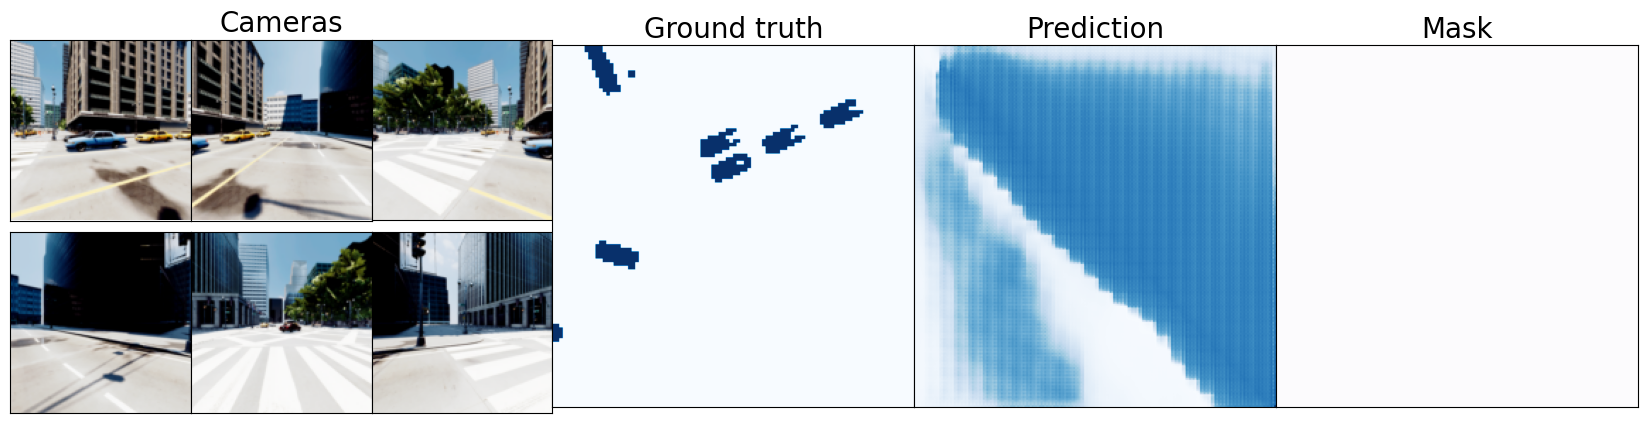

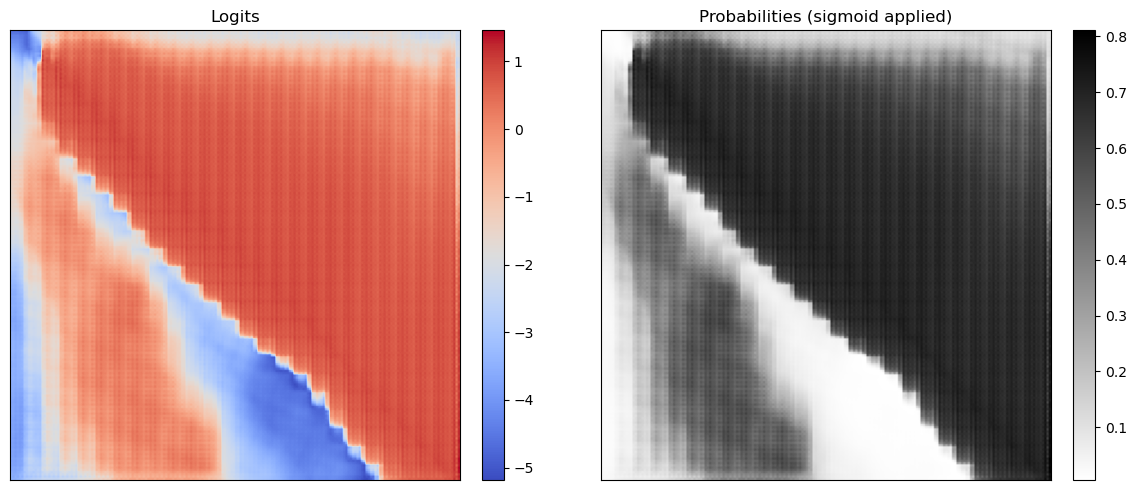

In [59]:
from torchvision.transforms.functional import to_pil_image

cmap = "Blues"

#############################################################################################

def visualise(imgs, data, out, b_ts=0, t_ts=0):
    key = "binimg"
    visibility = data.get("visibility", torch.ones_like(data[key]))
    
    # Prepare the images
    cam_imgs = [utils.imgs.DENORMALIZE_IMG(imgs[b_ts, t_ts, cam]) for cam in range(6)]
    bev_imgs = torch.cat(
        [
            # Ground truth
            (
                data[key]
                * ((visibility >= 2) * 2 + (visibility >= 1))
            )[b_ts, t_ts],
            # Prediction
            out["bev"][key][b_ts, t_ts].detach().cpu().sigmoid(),
            out["masks"]["bev"][key][b_ts, t_ts].detach().cpu(),
        ]
    )
    
    # Modify to keep the same color map:
    bev_imgs[1][0,0] = 0
    bev_imgs[1][-1,-1] = 1

    # Create figure and axes
    fig = plt.figure(figsize=(4.2 * 5, 1 * 5))  # Adjust figsize as needed

    num_cols = 3 + 6
    gs = gridspec.GridSpec(2, num_cols, figure=fig, wspace=0.0, hspace=0.0)

    # Create the axis
    axs = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(num_cols - 6)]

    for idx, img in enumerate(cam_imgs):
        axs[idx].imshow(img)  # PIL images work out of the box
        axs[idx].set_xticks([])
        axs[idx].set_yticks([])
        # axs[idx].set_title(f"Camera {idx}", fontsize=12)


    axs[1].set_title("Cameras", fontsize=20)

    # BeV
    ax_gt = fig.add_subplot(gs[0:2, 3:5])
    ax_gt.imshow(bev_imgs[0], cmap=cmap)

    ax_pred = fig.add_subplot(gs[0:2, 5:7])
    ax_pred.imshow(bev_imgs[1], cmap=cmap)
    
    ax_mask = fig.add_subplot(gs[0:2, 7:9])
    ax_mask.imshow(bev_imgs[2], cmap=matplotlib.cm.Purples)
    

    for ax, title in zip([ax_gt, ax_pred, ax_mask], ["Ground truth", "Prediction", "Mask"]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=20)

    return fig


b_ts = data["frame_idx"].index(selected_frame)  # index within batch
fig = visualise(imgs, data, out, b_ts=b_ts, t_ts=0)
fig.show()
print(f"Frame index: {selected_frame}")

##############################################################################################

# Extract the logits and probabilities
logits = out["bev"]["binimg"][b_ts, 0, 0].detach().cpu().numpy()
probs  = torch.sigmoid(out["bev"]["binimg"][b_ts, 0, 0]).detach().cpu().numpy()

# Create the side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Logits
im0 = axs[0].imshow(logits, cmap="coolwarm")
axs[0].set_title("Logits")
axs[0].set_xticks([])
axs[0].set_yticks([])
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# Probabilities
im1 = axs[1].imshow(probs, cmap="binary")
axs[1].set_title("Probabilities (sigmoid applied)")
axs[1].set_xticks([])
axs[1].set_yticks([])
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



In [60]:
# Visualization - 1. Feature Extraction (backbone_output)

Type of backbone_output: <class 'collections.OrderedDict'>
  Key out0: shape torch.Size([6, 56, 16, 16])
  Key out1: shape torch.Size([6, 160, 8, 8])

===== Processing out0 - Shape: torch.Size([6, 56, 16, 16]) =====



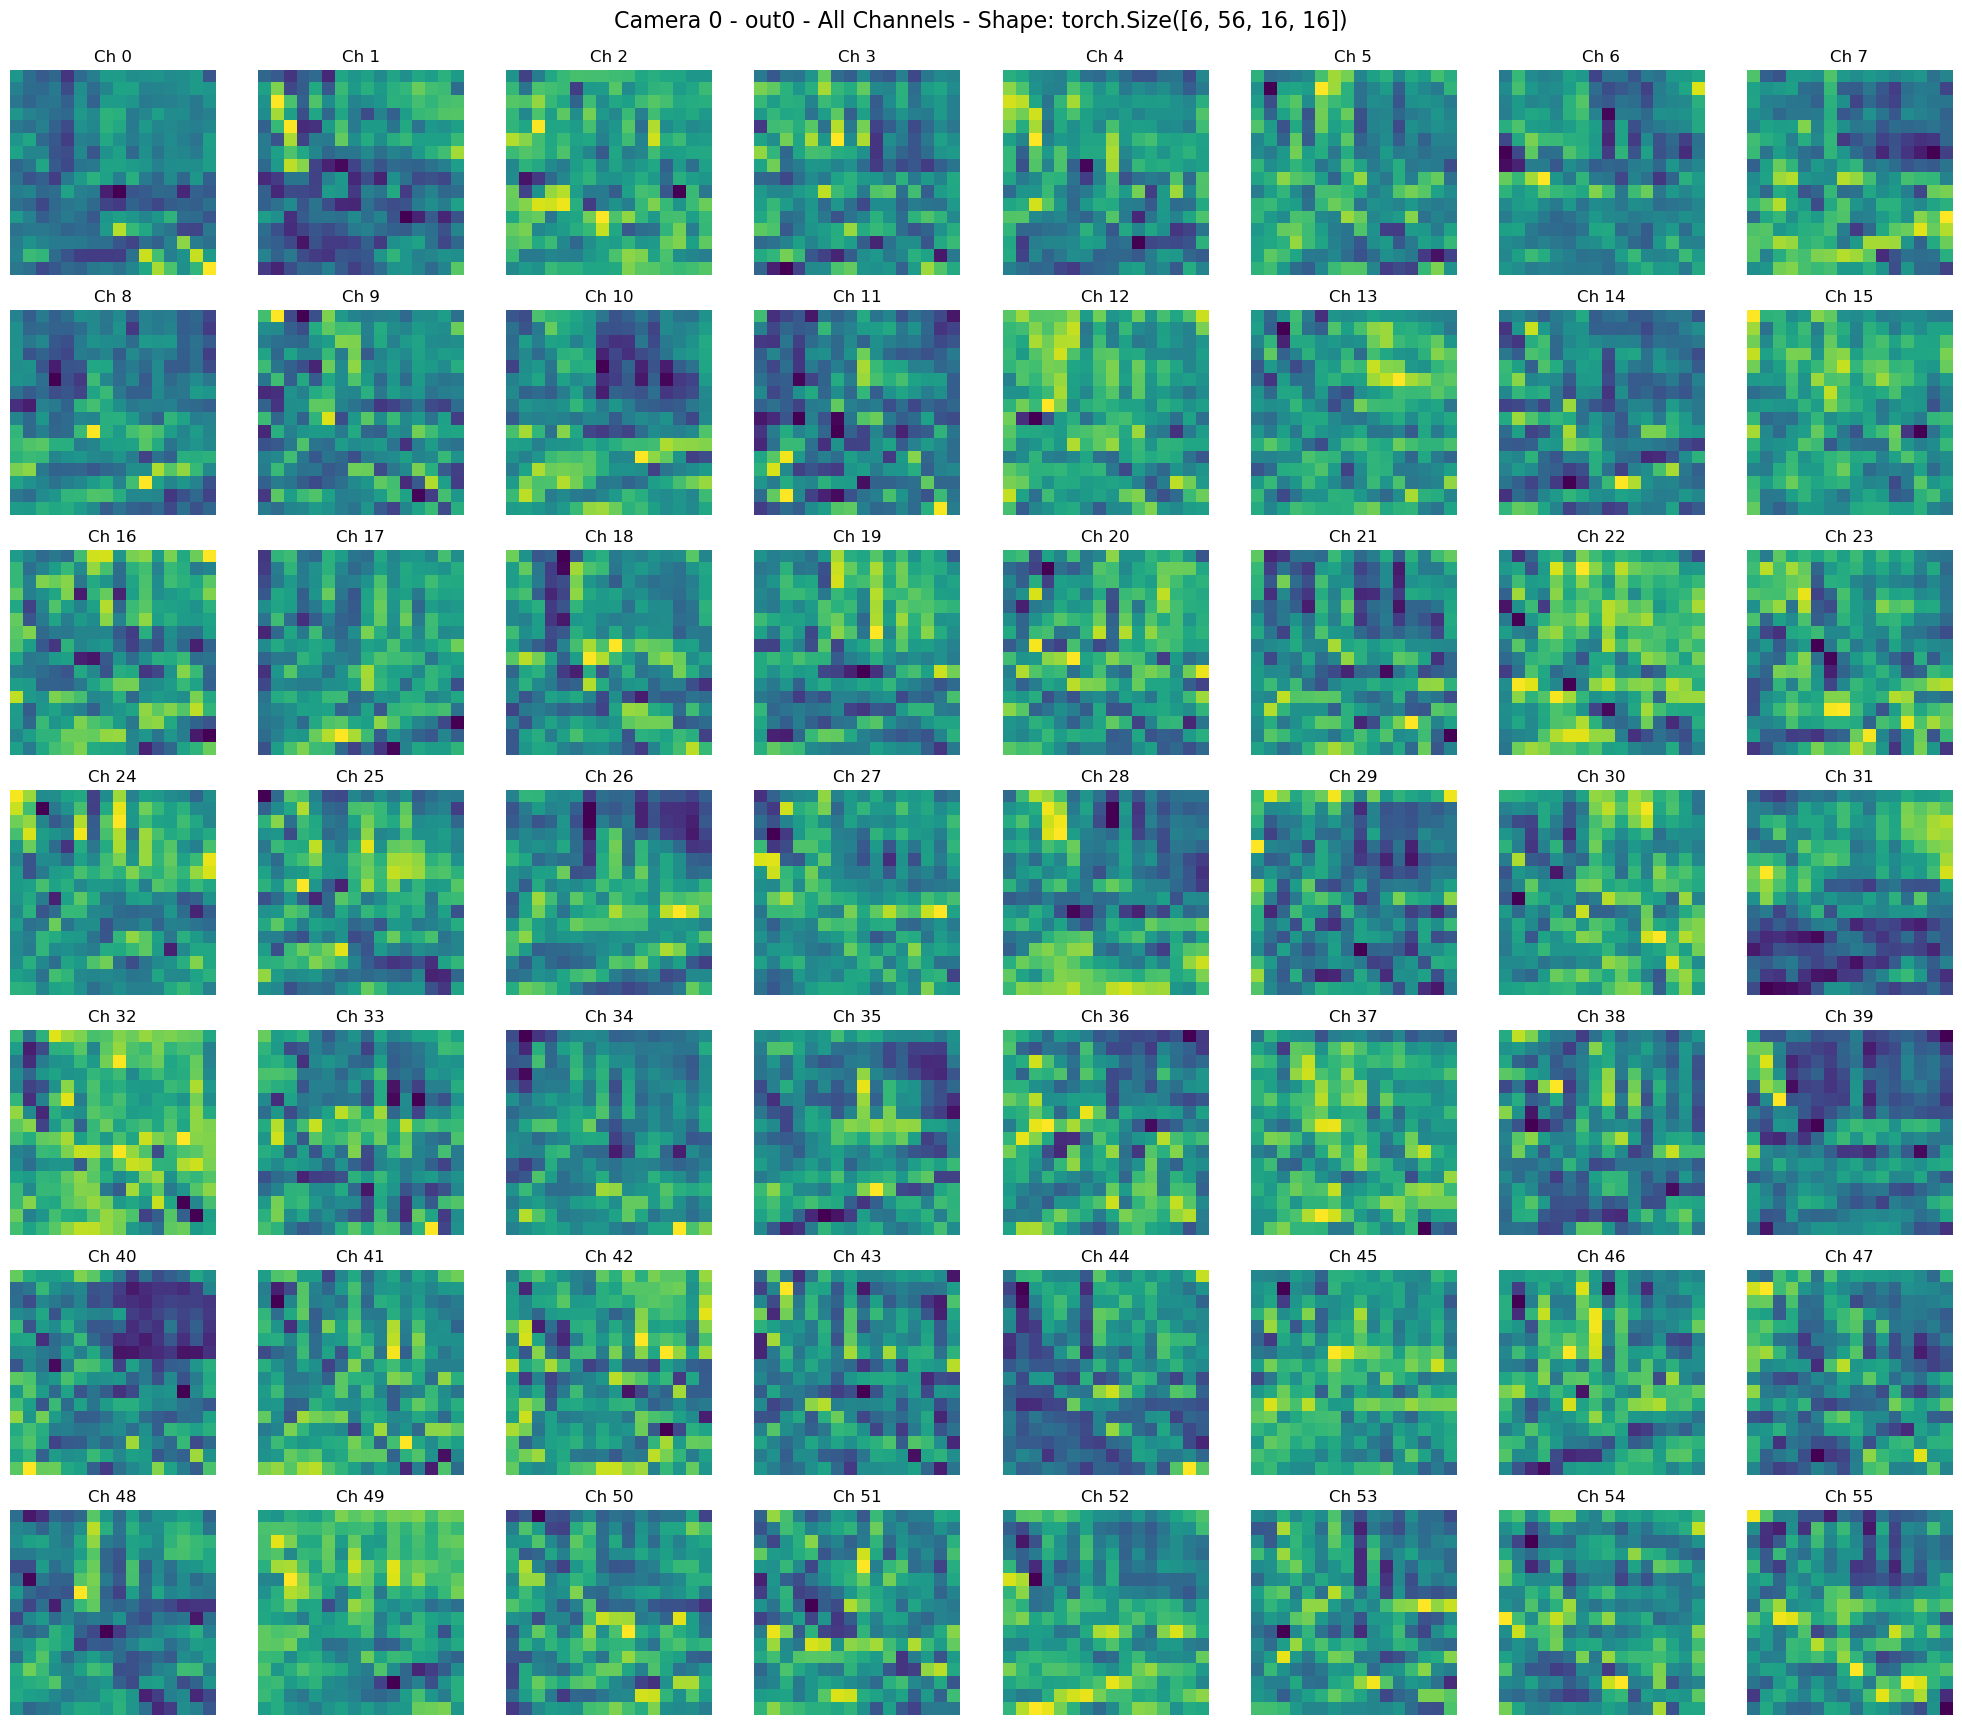


===== Processing out1 - Shape: torch.Size([6, 160, 8, 8]) =====



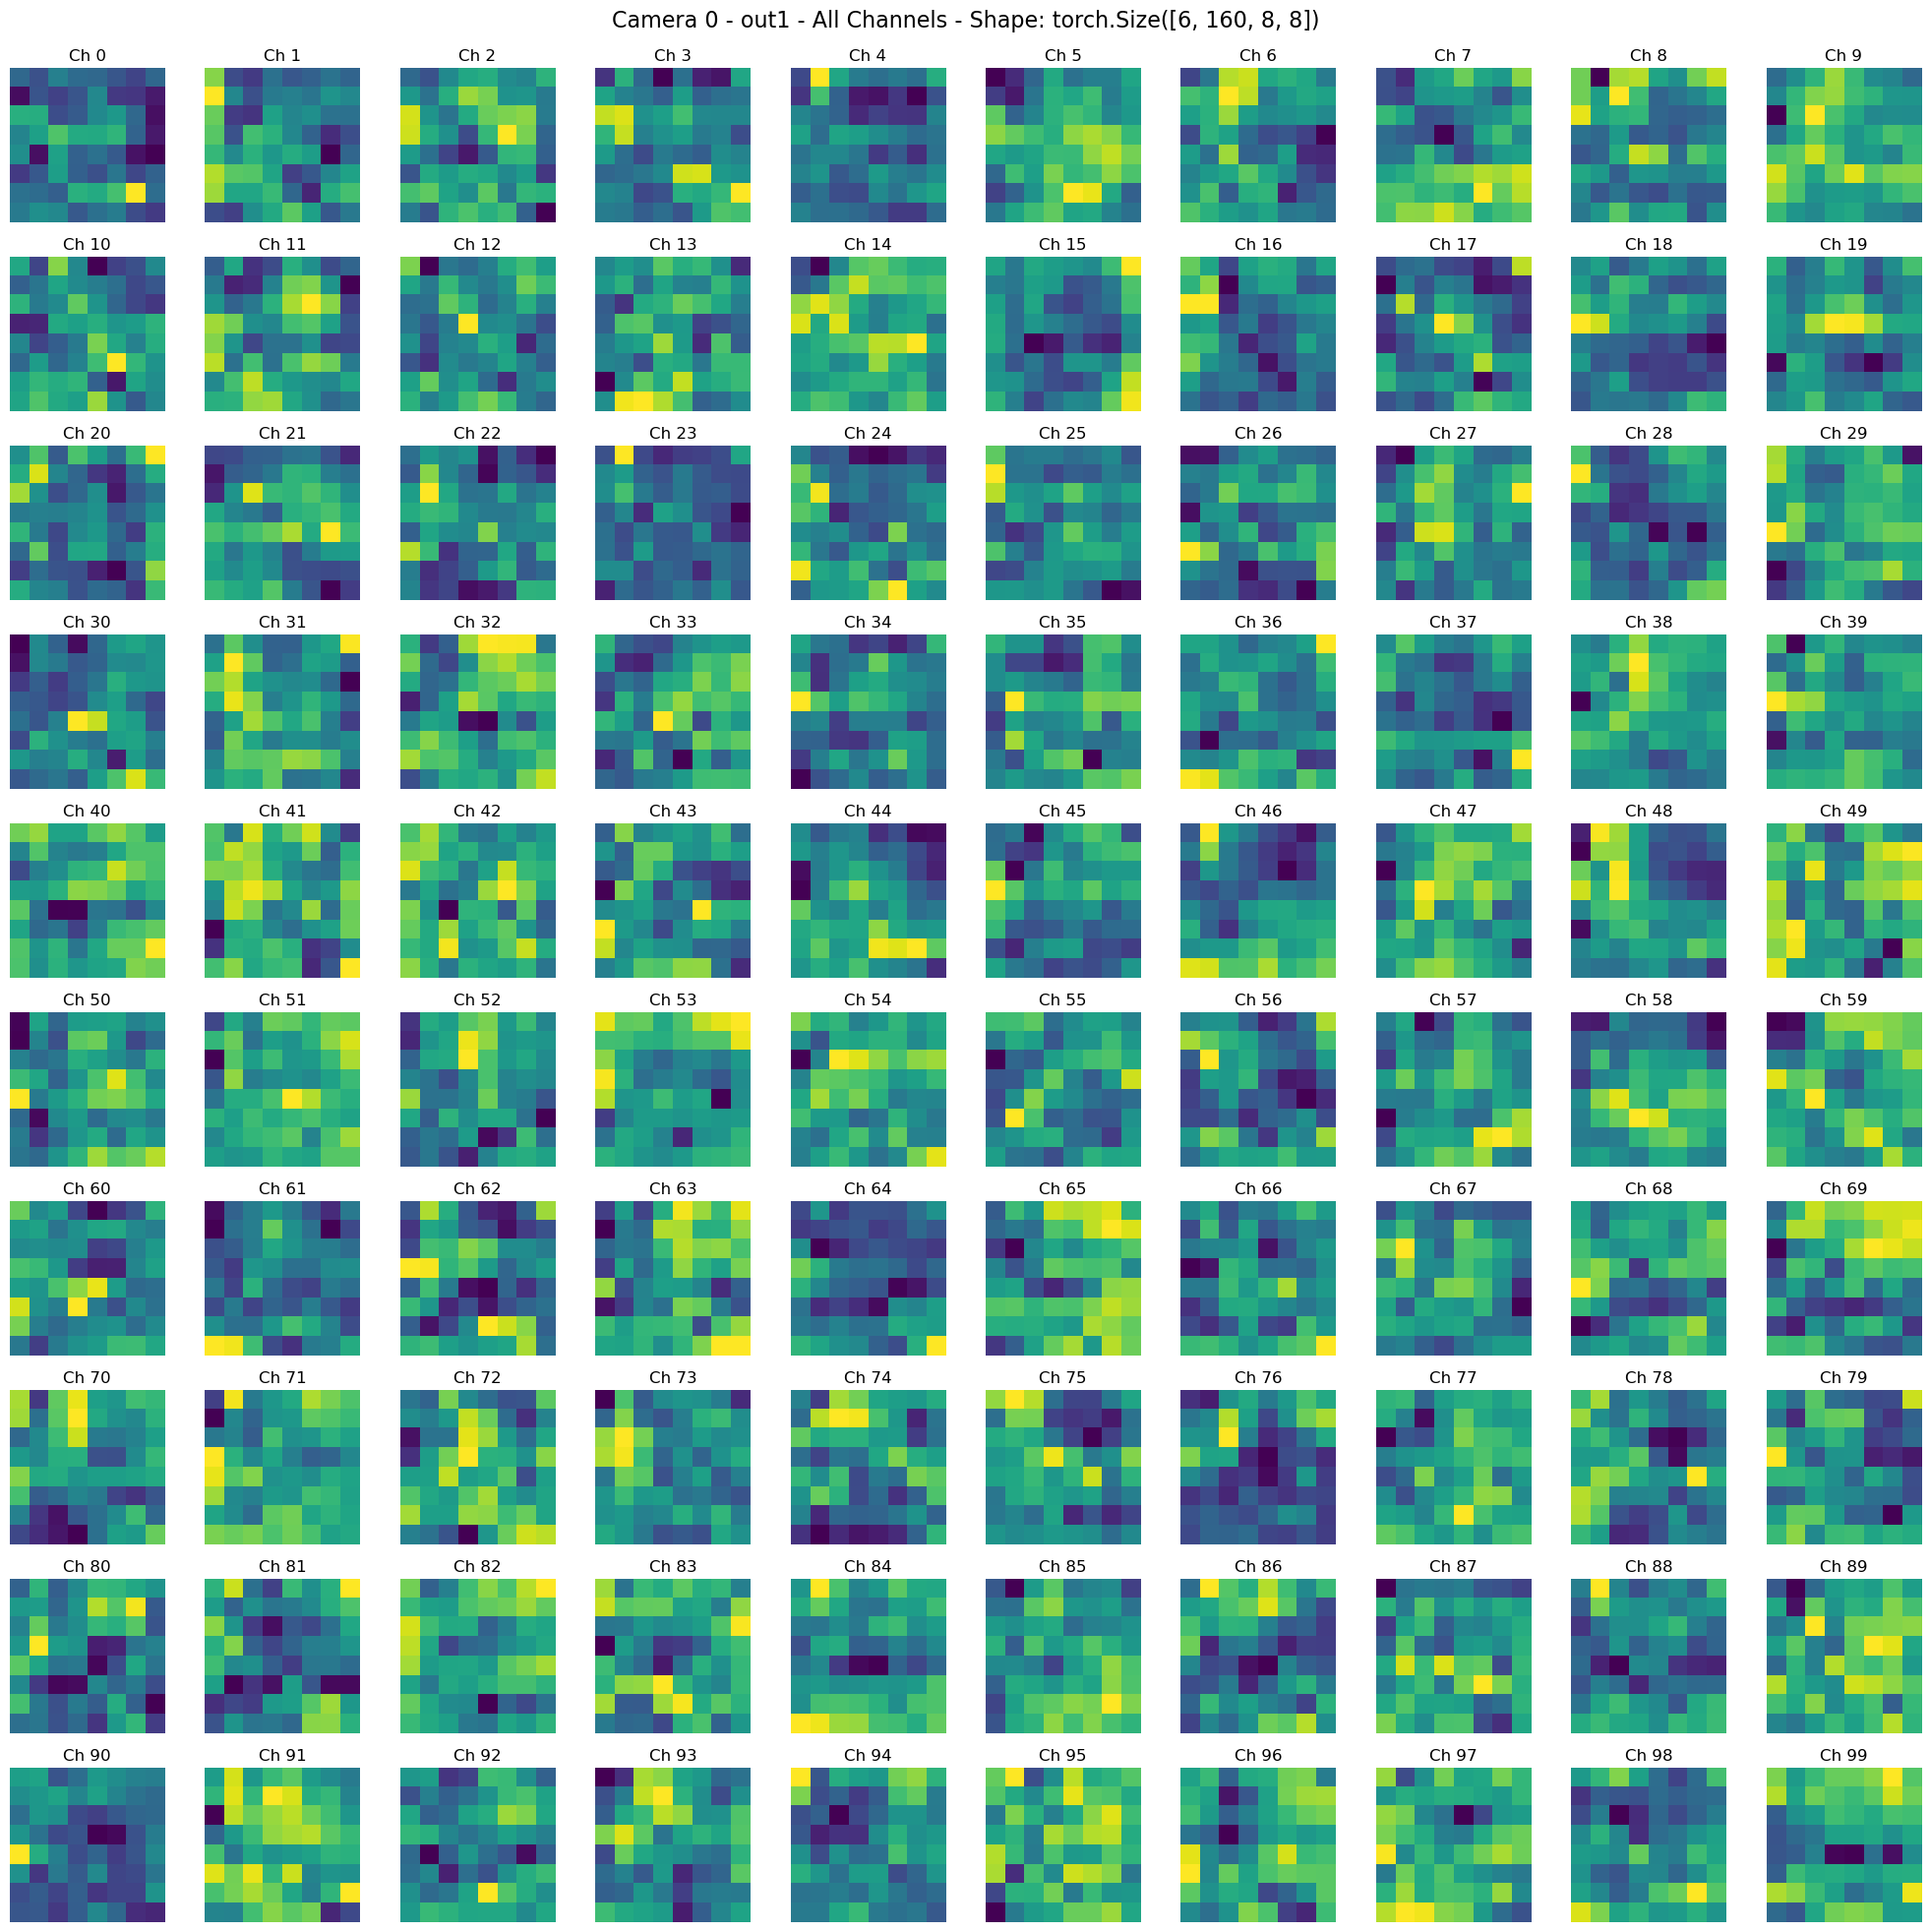

Only showing first 100 of 160 channels


In [61]:

# Register hook
features = {}
def hook_fn(module, input, output):
    features['backbone_output'] = output

# Find the backbone and register hook
model.net.backbone.register_forward_hook(hook_fn)

# Create a proper batch dict instead of separate arguments
batch = {
    "imgs": imgs,
    "rots": rots,
    "trans": trans,
    "intrins": intrins,
    "bev_aug": bev_aug,
    "egoTin_to_seq": egoTin_to_seq
}

# Run inference with the batch dict
with torch.no_grad():
    out = model(batch)  # Pass the entire batch dict

# Now visualize features as before
backbone_features = features['backbone_output']

# First, inspect what we actually got
print(f"Type of backbone_output: {type(features['backbone_output'])}")

# If it's an OrderedDict (typical for EfficientNet)
if hasattr(features['backbone_output'], 'items'):
    for k, v in features['backbone_output'].items():
        print(f"  Key {k}: shape {v.shape}")
else:
    print(f"Shape: {features['backbone_output'].shape}")

# Plot all channels for each camera for both output levels
def plot_all_channels(feature_maps, output_name, max_channels_per_plot=100):
    # For each camera
    for cam_idx in range(1): # only front camera interesting right now. feature_maps.shape[0]
        # Get feature map for this camera
        feat = feature_maps[cam_idx]  # [C, H, W]
        num_channels = feat.shape[0]
        
        # Determine grid size for subplot
        grid_size = int(np.ceil(np.sqrt(min(num_channels, max_channels_per_plot))))
        
        # Create figure
        plt.figure(figsize=(20, 20))
        
        # Plot each channel
        for i in range(min(num_channels, max_channels_per_plot)):
            plt.subplot(grid_size, grid_size, i+1)
            channel = feat[i].cpu().numpy()
            plt.imshow(channel, cmap='viridis')
            plt.title(f'Ch {i}')
            plt.axis('off')
            
        plt.suptitle(f'Camera {cam_idx} - {output_name} - All Channels - Shape: {feature_maps.shape}', fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()
        
        # If there are more channels than max_channels_per_plot, show a message
        if num_channels > max_channels_per_plot:
            print(f"Only showing first {max_channels_per_plot} of {num_channels} channels")

# Plot all channels for both output levels
for key, feature_maps in features['backbone_output'].items():
    print(f"\n===== Processing {key} - Shape: {feature_maps.shape} =====\n")
    plot_all_channels(feature_maps, key)

Keys in features: dict_keys([])
Keys in out: dict_keys(['bev', 'masks', 'tracks'])


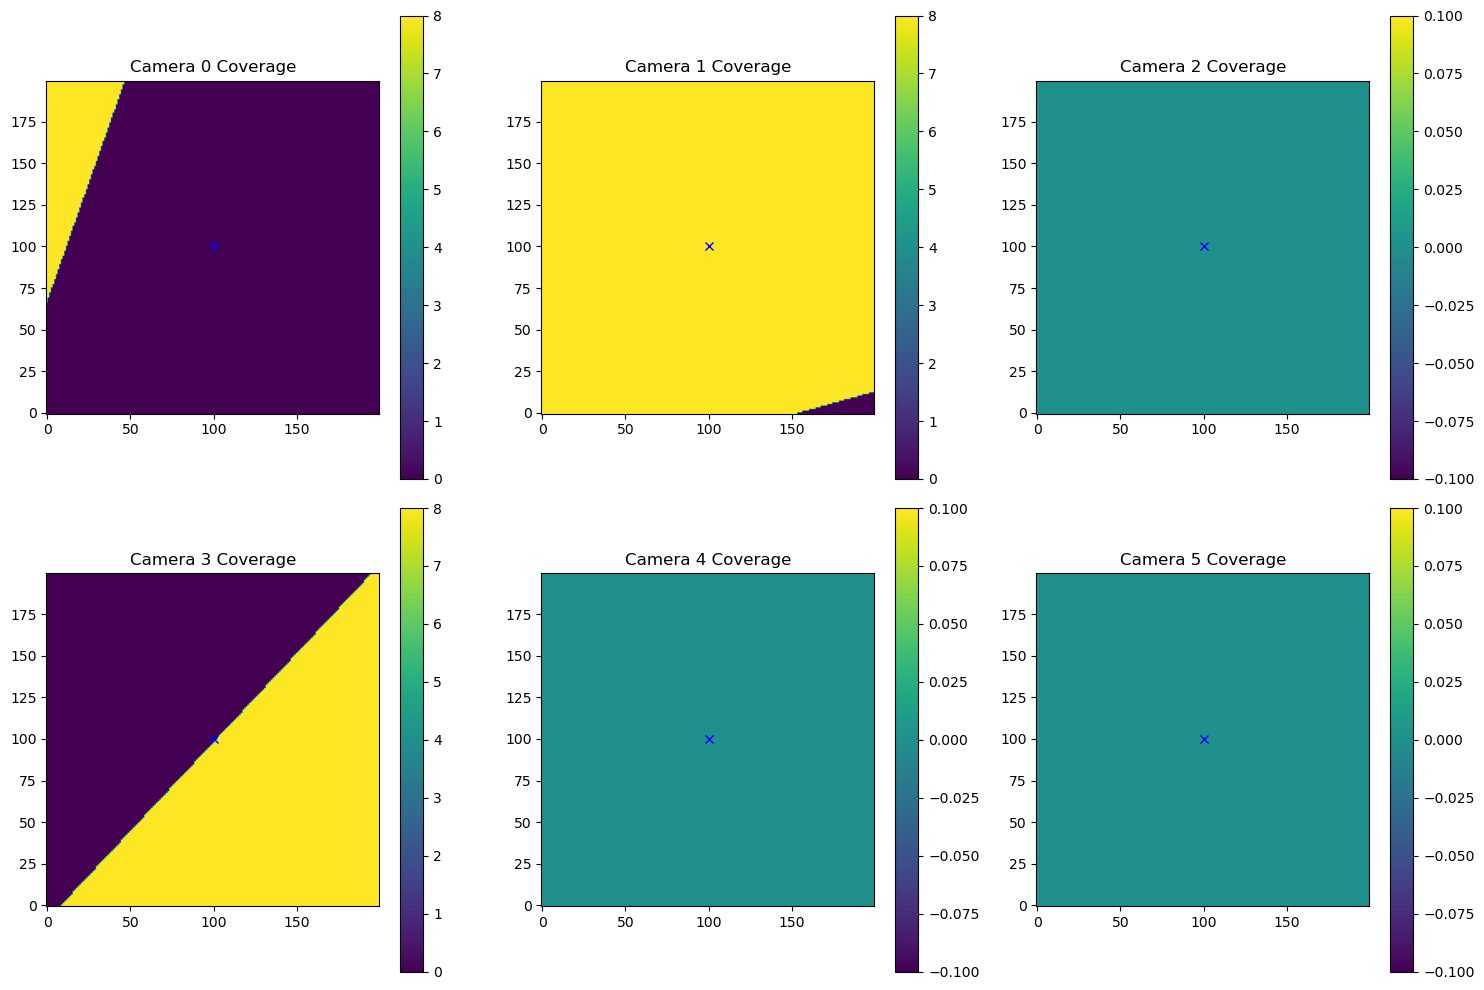

In [62]:
# # Make sure plots are displayed inline in notebook
import matplotlib.pyplot as plt
import numpy as np
# Register hooks to capture the outputs we need
features = {}

def backbone_hook(module, input, output):
    features['backbone_output'] = output
    
def projector_hook(module, input, output):
    features['projector_output'] = output
    
def view_transform_hook(module, input, output):
    features['bev_features'] = output

# Register all hooks
model.net.backbone.register_forward_hook(backbone_hook)
model.net.projector.register_forward_hook(projector_hook)
model.net.view_transform.register_forward_hook(view_transform_hook)

print("Keys in features:", features.keys())
print("Keys in out:", out.keys())

# Run inference - THIS LINE WAS MISSING
with torch.no_grad():
    out = model(batch)  # <-- Execute the forward pass to trigger hooks

# Run inference
batch = {
    "imgs": imgs,
    "rots": rots,
    "trans": trans,
    "intrins": intrins,
    "bev_aug": bev_aug, 
    "egoTin_to_seq": egoTin_to_seq
}



# # Check rotation matrices
# for cam_idx in range(6):
#     R = rots[0, 0, cam_idx].cpu().numpy()
#     cam_names = ['front', 'front_left', 'front_right', 'back_left', 'back_right', 'back']
#     print(f"{cam_names[cam_idx]} rotation matrix:")
#     print(R)
    
#     # Check forward vector
#     forward = R @ np.array([0, 0, 1])
#     print(f"  Forward vector: {forward}\n")



if 'projector_output' in features:
    vox_valid = features['projector_output']['vox_valid']
    
    # Create a figure for individual camera projections
    plt.figure(figsize=(15, 10))
    
    for cam_idx in range(6):
        plt.subplot(2, 3, cam_idx+1)
        # Sum over height dimension to get BEV view
        # Comment: there are 8 dimensions and if all are 1 (valid / seen by the camera), then the sum is 8
        cam_proj = vox_valid[0, 0, cam_idx].sum(dim=1).squeeze().cpu().numpy()
        plt.imshow(cam_proj, cmap='viridis', origin='lower') # makes that x,y = 0,0 is bottom left
        plt.title(f"Camera {cam_idx} Coverage")
        plt.colorbar()
        
        # Mark center
        plt.plot(100, 100, 'bx')
    
    plt.tight_layout()
    plt.show()
else: 
    print("No projector output found. Skipping projection visualization.")



# # Check if projection is using the wrong origin with zoomed out view
# if 'projector_output' in features:
#     vox_valid = features['projector_output']['vox_valid']
    
#     # Create figure showing all cameras with wide context
#     plt.figure(figsize=(18, 15))
    
#     # For each camera
#     for cam_idx in range(6):
#         cam_names = ['front', 'front_left', 'front_right', 'back_left', 'back_right', 'back']
#         cam_valid = vox_valid[0, 0, cam_idx].sum(dim=1).squeeze().cpu().numpy()
        
#         plt.subplot(2, 3, cam_idx+1)
        
#         # 1. Create a larger canvas to see beyond grid boundaries
#         canvas = np.zeros((400, 400))  # Larger canvas
        
#         # 2. Place the actual data in the center of this canvas
#         h, w = cam_valid.shape
#         start_h, start_w = (400-h)//2, (400-w)//2
#         canvas[start_h:start_h+h, start_w:start_w+w] = cam_valid
        
#         # 3. Display the canvas
#         plt.imshow(canvas, cmap='hot', origin='lower')
#         plt.title(f"Camera {cam_idx} ({cam_names[cam_idx]})")
        
#         # 4. Mark grid boundaries
#         plt.plot([start_w, start_w+w-1, start_w+w-1, start_w, start_w], 
#                  [start_h, start_h, start_h+h-1, start_h+h-1, start_h], 
#                  'w--', alpha=0.5)
        
#         # 5. Mark grid center
#         grid_center_x, grid_center_y = start_w + 100, start_h + 100
#         plt.plot(grid_center_x, grid_center_y, 'bx', markersize=10)
#         plt.text(grid_center_x+5, grid_center_y+5, "Grid Center", color='blue')
        
#         # 6. Try to identify the actual origin through linear extrapolation
#         # Find non-zero points
#         y_indices, x_indices = np.nonzero(cam_valid)
        
#         if len(y_indices) > 10:  # Need enough points for a meaningful line
#             # Get furthest 20% of points from grid center for better line fitting
#             dists = (y_indices - 100)**2 + (x_indices - 100)**2
#             idx = np.argsort(dists)[-int(len(dists)*0.2):]
            
#             # Simple linear regression to find line of best fit
#             from sklearn.linear_model import LinearRegression
#             X = x_indices[idx].reshape(-1, 1)
#             y = y_indices[idx].reshape(-1, 1)
#             reg = LinearRegression().fit(X, y)
            
#             # Draw the regression line across the canvas
#             x_line = np.array([0, 400]).reshape(-1, 1)
#             y_line = reg.predict(x_line)
            
#             # Draw the line
#             plt.plot(x_line + start_w, y_line + start_h, 'g-', linewidth=2)
            
#             # Calculate and mark the y-intercept (where x=0, potentially the origin)
#             x_intercept = -reg.intercept_[0] / reg.coef_[0][0] if reg.coef_[0][0] != 0 else 0
#             y_intercept = reg.intercept_[0]
            
#             # Mark the estimated origin (if within canvas)
#             origin_x, origin_y = start_w + x_intercept, start_h + y_intercept
#             if 0 <= origin_x < 400 and 0 <= origin_y < 400:
#                 plt.plot(origin_x, origin_y, 'ro', markersize=8)
#                 plt.text(origin_x+5, origin_y+5, f"Est. Origin", color='red')
        
#         plt.colorbar()
    
#     plt.tight_layout()
#     plt.suptitle("Camera Coverage with Expanded View", fontsize=16)
#     plt.subplots_adjust(top=0.93)
#     plt.show()
    
#     # Also add a combined view of all cameras
#     plt.figure(figsize=(10, 10))
#     combined_coverage = np.zeros_like(cam_valid)
    
#     for cam_idx in range(6):
#         cam_cov = vox_valid[0, 0, cam_idx].sum(dim=1).squeeze().cpu().numpy()
#         combined_coverage += cam_cov
    
#     plt.imshow(combined_coverage, cmap='hot', origin='lower')
#     plt.title("Combined Coverage of All Cameras")
#     plt.colorbar(label="Sum of Camera Coverage")
#     plt.plot(100, 100, 'bx', markersize=10, label="Grid Center")
#     plt.legend()
#     plt.show()

In [63]:
# Visualization - 2. 3D Projection (projector_output)

vox_valid shape: torch.Size([1, 1, 6, 200, 8, 200, 1])
Reshaped coverage: (200, 200)


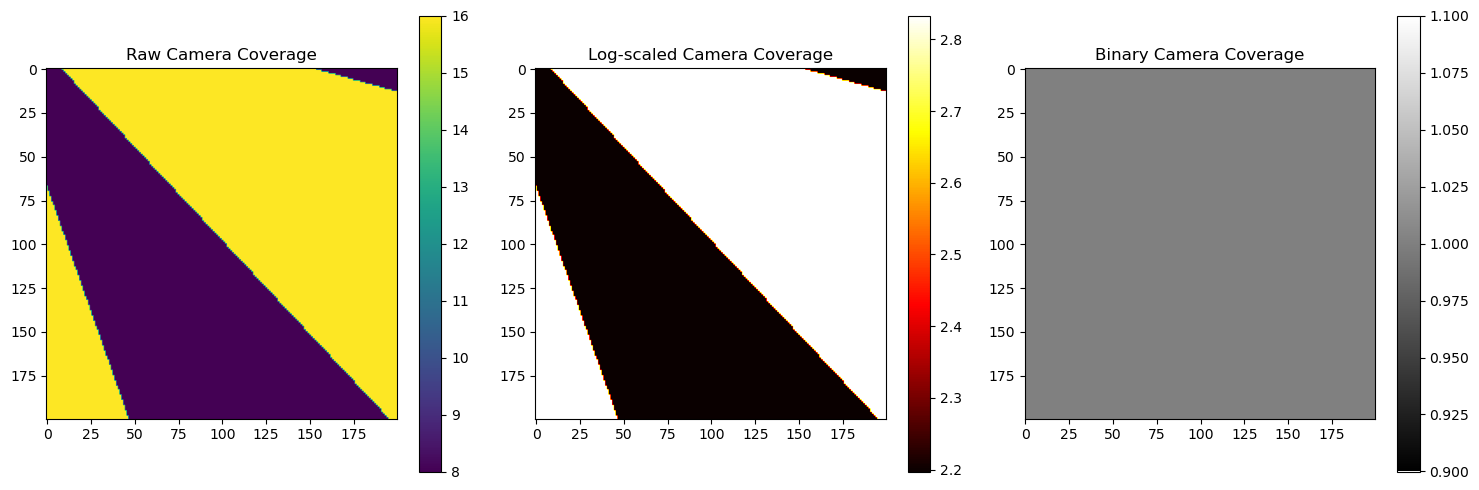

After squeeze: BEV grid shape: (200, 200), Camera coverage shape: (200, 200)


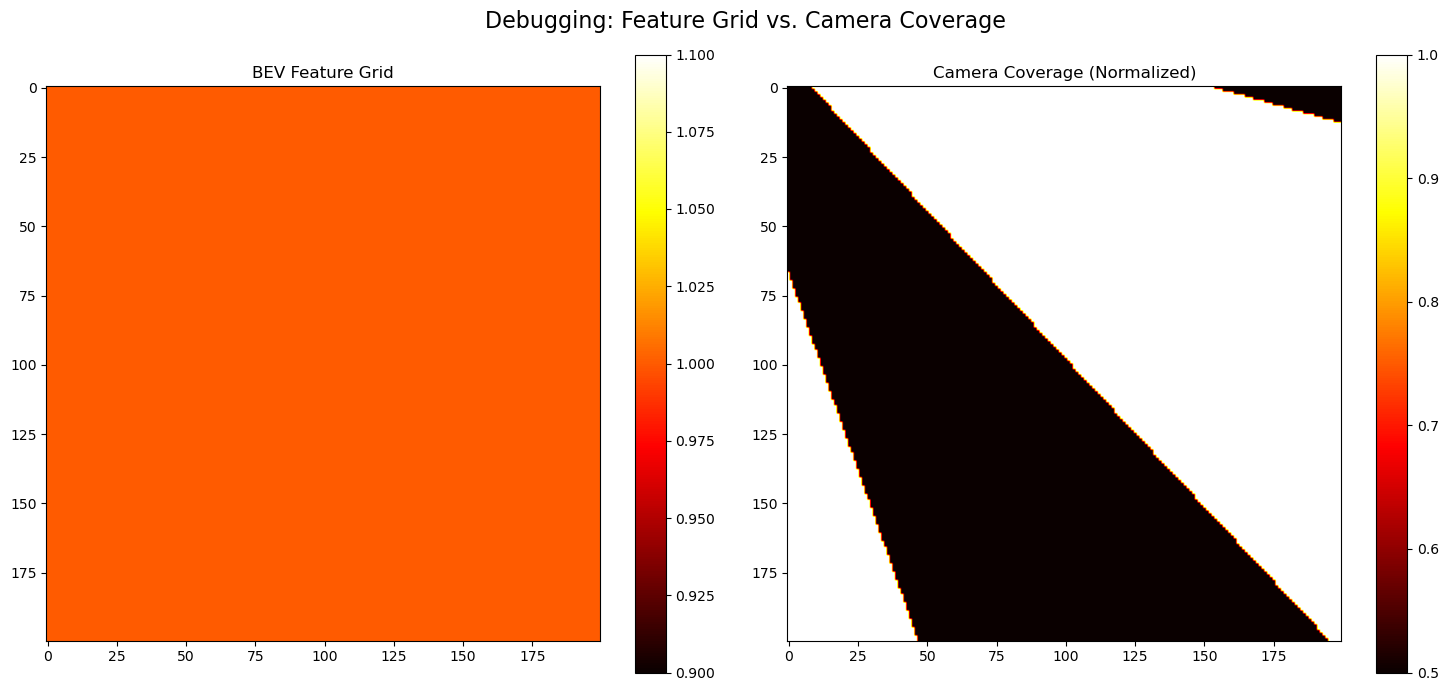

Percentage of grid marked as valid: 100.00%
BEV grid shape: torch.Size([1, 1, 1, 200, 200])


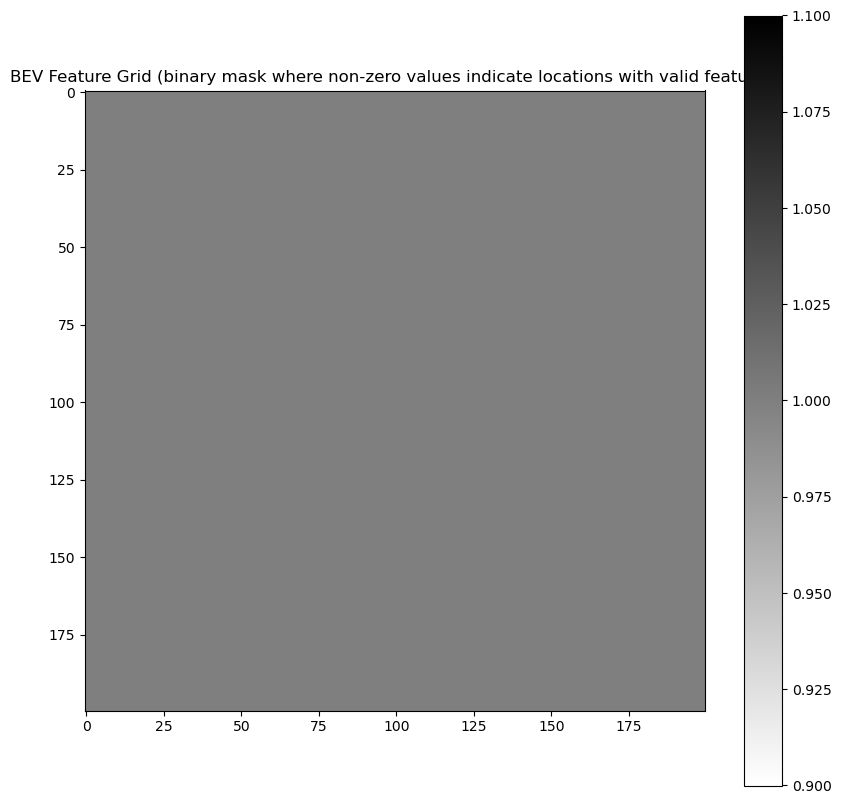

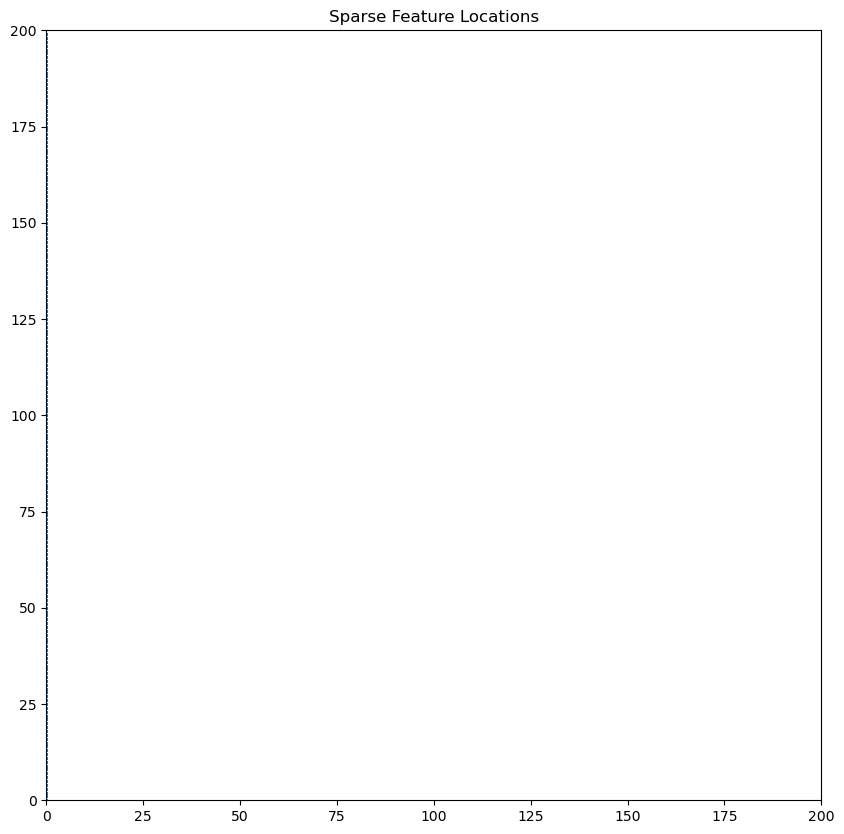

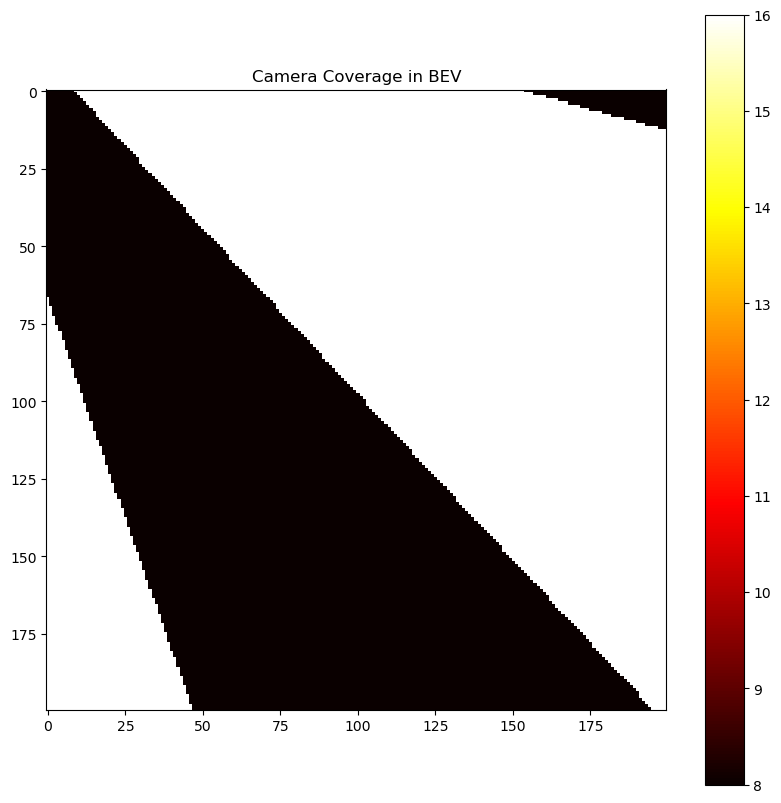

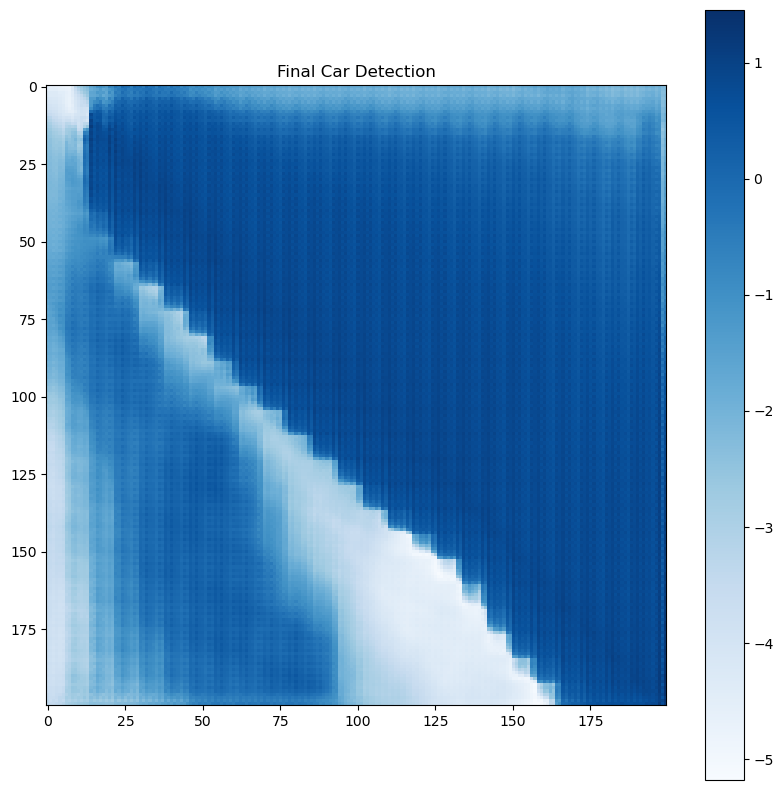

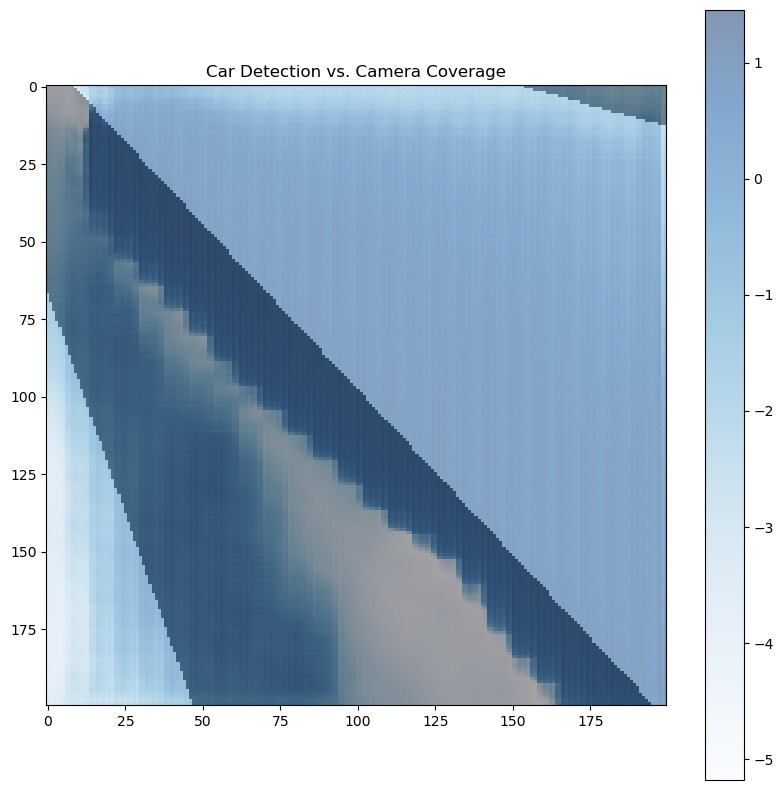

In [64]:
# # Make sure plots are displayed inline in notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# Register hooks to capture the outputs we need
features = {}

def backbone_hook(module, input, output):
    features['backbone_output'] = output
    
def projector_hook(module, input, output):
    features['projector_output'] = output
    
def view_transform_hook(module, input, output):
    features['bev_features'] = output

# Register all hooks
model.net.backbone.register_forward_hook(backbone_hook)
model.net.projector.register_forward_hook(projector_hook)
model.net.view_transform.register_forward_hook(view_transform_hook)

# Run inference
batch = {
    "imgs": imgs,
    "rots": rots,
    "trans": trans,
    "intrins": intrins,
    "bev_aug": bev_aug, 
    "egoTin_to_seq": egoTin_to_seq
}

with torch.no_grad():
    out = model(batch)


# Fix camera coverage visualization
if 'projector_output' in features:
    vox_valid = features['projector_output']['vox_valid']
    
    # Print shape information
    print(f"vox_valid shape: {vox_valid.shape}")
    
    # Sum across cameras (dim=2) and height (dim=4)
    cam_coverage = vox_valid[0, 0].sum(dim=0).sum(dim=1)
    
    # Ensure proper shape
    cam_coverage = cam_coverage.squeeze().cpu().numpy()
    print(f"Reshaped coverage: {cam_coverage.shape}")
    
    # Try different normalization methods and colormaps
    plt.figure(figsize=(15, 5))
    
    plt.subplot(131)
    plt.imshow(cam_coverage, cmap='viridis')
    plt.colorbar()
    plt.title("Raw Camera Coverage")
    
    plt.subplot(132)
    # Log scale often helps with uneven distributions
    log_coverage = np.log1p(cam_coverage)  # log(1+x) to handle zeros
    plt.imshow(log_coverage, cmap='hot')
    plt.colorbar()
    plt.title("Log-scaled Camera Coverage")
    
    plt.subplot(133)
    # Threshold to binary for clear visibility areas
    binary = cam_coverage > 0
    plt.imshow(binary, cmap='gray')
    plt.colorbar()
    plt.title("Binary Camera Coverage")
    
    plt.tight_layout()
    plt.show()

# Fix the camera coverage shape
if 'bev_features' in features and 'projector_output' in features:
    # Get the feature grid (already correct at 200x200)
    bev_grid_vis = features['bev_features'][1][0, 0, 0].cpu().numpy()
    
    # Get camera coverage and properly reshape
    vox_valid = features['projector_output']['vox_valid']
    cam_coverage = vox_valid[0, 0].sum(dim=0).sum(dim=1).cpu().numpy()
    # Explicitly squeeze out the extra dimension
    cam_coverage = np.squeeze(cam_coverage)
    
    print(f"After squeeze: BEV grid shape: {bev_grid_vis.shape}, Camera coverage shape: {cam_coverage.shape}")
    
    
    # Check if shapes match, reshape if needed
    if bev_grid_vis.shape != cam_coverage.shape:
        print(f"Shape mismatch! Reshaping for comparison.")
        # Ensure both are 2D arrays of same shape
        if len(bev_grid_vis.shape) > 2:
            bev_grid_vis = bev_grid_vis.reshape(bev_grid_vis.shape[0], bev_grid_vis.shape[1])
        if len(cam_coverage.shape) > 2:
            cam_coverage = cam_coverage.reshape(cam_coverage.shape[0], cam_coverage.shape[1])
    
    # Normalize camera coverage
    if cam_coverage.max() > 0:
        cam_coverage_norm = cam_coverage / cam_coverage.max()
    else:
        cam_coverage_norm = cam_coverage
    
    # Create side-by-side comparison (only 2 plots instead of 3 to avoid the difference calculation)
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    
    # Plot feature grid
    im0 = axs[0].imshow(bev_grid_vis, cmap='hot')
    axs[0].set_title("BEV Feature Grid")
    plt.colorbar(im0, ax=axs[0])
    
    # Plot camera coverage
    im1 = axs[1].imshow(cam_coverage_norm, cmap='hot')
    axs[1].set_title("Camera Coverage (Normalized)")
    plt.colorbar(im1, ax=axs[1])
    
    plt.suptitle("Debugging: Feature Grid vs. Camera Coverage", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Additional analysis
    valid_percentage = 100.0 * np.sum(bev_grid_vis > 0) / bev_grid_vis.size
    print(f"Percentage of grid marked as valid: {valid_percentage:.2f}%")




# Visualize BEV feature grid
if 'bev_features' in features:
    # Extract the feature grid (second element in the tuple)
    bev_grid = features['bev_features'][1]
    print(f"BEV grid shape: {bev_grid.shape}")
    
    # Normalize for better visualization
    bev_grid_vis = bev_grid[0, 0, 0].cpu().numpy()
    
    # Plot the feature grid
    # EXPECTED BEHAVIOR:
    # Higher values near the ego vehicle where camera coverage is better
    # Lower or zero values in regions outside camera field-of-view
    # Some pattern that reflects the camera arrangement and visible areas
    plt.figure(figsize=(10, 10))
    plt.imshow(bev_grid_vis, cmap='binary')
    plt.title("BEV Feature Grid (binary mask where non-zero values indicate locations with valid features)")
    plt.colorbar()
    plt.show()
    
    # Visualize sparse feature locations
    coords = features['bev_features'][2].cpu().numpy()
    if coords.shape[1] >= 2:
        plt.figure(figsize=(10, 10))
        plt.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.5)
        plt.title("Sparse Feature Locations")
        plt.xlim(0, 200)
        plt.ylim(0, 200)
        plt.show()
        
    # Compare with projector output
    if 'projector_output' in features:
        vox_valid = features['projector_output']['vox_valid']
        # Sum across cameras to see coverage from all cameras
        cam_coverage = vox_valid[0, 0].sum(dim=0).sum(dim=1).cpu().numpy()
        
        plt.figure(figsize=(10, 10))
        plt.imshow(cam_coverage, cmap='hot')
        plt.title("Camera Coverage in BEV")
        plt.colorbar()
        plt.show()
        
        # And show the final segmentation result
        if 'bev' in out and isinstance(out['bev'], dict) and 'binimg' in out['bev']:
            binimg = out['bev']['binimg']
            while len(binimg.shape) > 2 and binimg.shape[0] == 1:
                binimg = binimg[0]
                
            plt.figure(figsize=(10, 10))
            plt.imshow(binimg.cpu().numpy(), cmap='Blues')
            plt.title("Final Car Detection")
            plt.colorbar()
            plt.show()
            
            # Overlay detection on camera coverage
            plt.figure(figsize=(10, 10))
            plt.imshow(cam_coverage, cmap='hot', alpha=0.7)
            plt.imshow(binimg.cpu().numpy(), cmap='Blues', alpha=0.5)
            plt.title("Car Detection vs. Camera Coverage")
            plt.colorbar()
            plt.show()

Create a clip

In [65]:
# # Transform to convert PyTorch tensor to PIL image
# transform = transforms.ToPILImage()

# # Generating frames using the model
# iter_loader = iter(datamodule.val_dataloader())

# max_frames = 50

In [66]:
# frames = []  # List to hold frames
# frame_filenames = []

# for frame_number in trange(max_frames):  # Iterate over your data
#     input_data = next(iter_loader)
#     data = datamodule.on_after_batch_transfer(input_data, None)

#     imgs = data["imgs"].to(device)
#     rots = data["rots"].to(device)
#     trans = data["trans"].to(device)
#     intrins = data["intrins"].to(device)
#     bev_aug = data["bev_aug"].to(device)
#     egoTin_to_seq = data["egoTin_to_seq"].to(device)
#     egoTout_to_seq = data["egoTout_to_seq"].to(device)

#     with torch.inference_mode():
#         with torch.no_grad():
#             out = self(imgs, rots, trans, intrins, bev_aug, egoTin_to_seq)

#     fig = visualise(imgs, data, out)
#     frame_filename = f"frame_{frame_number}.png"
#     plt.savefig(frame_filename, bbox_inches="tight")
#     frame_filenames.append(frame_filename)
#     plt.close()

# # Create GIF from frames
# frames = [Image.open(image) for image in frame_filenames]
# frames[0].save(
#     "../notebooks/test.gif",
#     format="GIF",
#     append_images=frames[1:],
#     save_all=True,
#     duration=1000,
#     loop=0,
# )

# # Optional: Clean up by removing individual frame files
# for filename in frame_filenames:
#     os.remove(filename)